In [22]:
import uproot
import numpy as np
import pandas as pd

def dist(file, PID = False, bins = 50, use_abs = False, name = False):
    file = uproot.open(file)
    tree = file["Delphes"]

    pid = tree["Particle/Particle.PID"].array(library = "np")
    pt = tree["Particle/Particle.PT"].array(library = "np")
    eta = tree["Particle/Particle.Eta"].array(library = "np")
    phi = tree["Particle/Particle.Phi"].array(library = "np")
    charge = tree["Particle/Particle.Charge"].array(library = "np")

    events = len(pt)

    if use_abs == True:
        ind = [[i, l] for i in range(events) for l in np.where(abs(pid[i]) == PID)[0]]
        pt_p = [pt[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        eta_p = [eta[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        phi_p = [phi[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        charge_p = [charge[ind[i][0]][ind[i][1]] for i in range(len(ind))]
    else:
        if PID >= 0:
            ind = [[i, l] for i in range(events) for l in np.where(pid[i] == PID)[0]]
            pt_p = [pt[ind[i][0]][ind[i][1]] for i in range(len(ind))]
            eta_p = [eta[ind[i][0]][ind[i][1]] for i in range(len(ind))]
            phi_p = [phi[ind[i][0]][ind[i][1]] for i in range(len(ind))]
            charge_p = [charge[ind[i][0]][ind[i][1]] for i in range(len(ind))]
        else:
            ind = [[i, l] for i in range(events) for l in np.where(pid[i] == PID)[0]]
            pt_t = [pt[ind[i][0]][ind[i][1]] for i in range(len(ind))]
            eta_t = [eta[ind[i][0]][ind[i][1]] for i in range(len(ind))]
            phi_t = [phi[ind[i][0]][ind[i][1]] for i in range(len(ind))]
            charge_t = [charge[ind[i][0]][ind[i][1]] for i in range(len(ind))]

            ind2 = [i for i, x in enumerate(pt_t) if (x > 0 and x < 1e6)]
            pt_p = [pt_t[ind2[i]] for i in range(len(ind2))]
            eta_p = [eta_t[ind2[i]] for i in range(len(ind2))]
            phi_p = [phi_t[ind2[i]] for i in range(len(ind2))]
            charge_p = [charge_t[ind2[i]] for i in range(len(ind2))]
            
    if name:
        data = {
            "P_t" + " "*1 + name: pt_p,
            "Eta" + " "*1 + name: eta_p,
            "Phi" + " "*1 + name: phi_p,
            "Charge" + " "*1 + name: charge_p
        }
    else:
        data = {
            "P_t": pt_p,
            "Eta": eta_p,
            "Phi": phi_p,
            "Charge": charge_p
        }
    data = pd.DataFrame(data)   
    data.hist(bins = bins) 
    return data

,P_t Anti Electrons,Eta Anti Electrons,Phi Anti Electrons,Charge Anti Electrons
0,11.478856,-0.275934,-1.223923,1
1,60.525475,0.697082,-0.352569,1
2,54.667545,0.697099,-0.352333,1
3,54.618896,0.697105,-0.352334,1
4,54.618896,0.697105,-0.352334,1
...,...,...,...,...
699624,76.273445,-0.132840,-1.886138,1
699625,76.273376,-0.132840,-1.886138,1
699626,75.467346,-0.132840,-1.886138,1
699627,67.231934,0.273141,2.987999,1


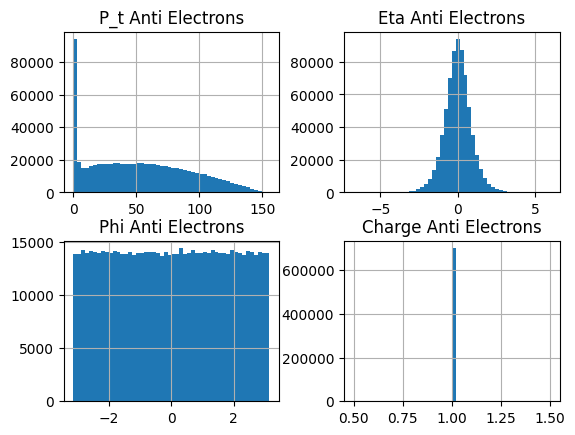

In [23]:
file = "/tf/Higgs-Boson-LHC-Collision-Detector/sigfcc_350.root"

dist(file, PID = -11, use_abs = False, bins = 50, name = "Anti Electrons")